
# Week 11 Hands-On: Refactoring an H$_2$ Hartree–Fock Script into a Python Class

## Motivation
Your earlier H$_2$ Hartree–Fock notebook works, but it is written in a **single-script style**:
- system setup, integrals, matrix construction, and diagonalization are all mixed together,
- the basis is treated as **non-orthogonal**, but that is not made explicit,
- the code is harder to reuse for a different bond length or a slightly different basis.

In this lesson, we will reorganize the code into a small, reusable Python class.  
That will make it easier to:
1. change the H–H bond length,
2. reuse the code for multiple calculations,
3. expose the role of the **overlap matrix** and **basis orthogonalization** clearly.

---

## Learning goals
By the end of this notebook, you should be able to:
- explain what a Python class is,
- distinguish between **attributes** and **methods**,
- explain why the AO basis for H$_2$ in STO-3G is **not orthogonal**,
- explain why your original notebook can still work **without explicitly orthogonalizing** the basis,
- implement **symmetric orthogonalization**,
- wrap the Hartree–Fock workflow into a small Python class,
- run an SCF calculation and extract orbital energies and the total energy.

---

## Plan for today
We will:
1. Construct a python class to describe and quantify aspects of a rectangle
2. build the needed one- and two-electron integrals for a minimal H$_2$ STO-3G model,
3. build a `Basis` class to contain all of the information necessary to define the basis functions
4. define a class `H2RHF`,
5. add a method for symmetric orthogonalization,
6. run the SCF cycle,
7. Compute and plot $E(R)$ vs $R$,
6. leave you with a few extension exercises.


## Part 1. A toy example: introducing Python classes

Before doing Hartree–Fock, let us introduce classes with a simple example.
A class is a way to bundle together:

- **data** describing an object, and
- **functions** that operate on that object.

For a first example, consider a `Rectangle`.


In [1]:
class Rectangle:
    def __init__(self, width, height):
        self.width = width
        self.height = height

    def area(self):
        return self.width * self.height

    def perimeter(self):
        return 2 * (self.width + self.height)

    def rescale(self, factor):
        self.width *= factor
        self.height *= factor

    def summary(self):
        print(f"Rectangle(width={self.width}, height={self.height})")
        print(f"Area      = {self.area()}")
        print(f"Perimeter = {self.perimeter()}")


In [2]:

box = Rectangle(3.0, 2.0)
box.summary()

print("\nNow rescale by a factor of 1.5\n")
box.rescale(1.5)
box.summary()


Rectangle(width=3.0, height=2.0)
Area      = 6.0
Perimeter = 10.0

Now rescale by a factor of 1.5

Rectangle(width=4.5, height=3.0)
Area      = 13.5
Perimeter = 15.0



### What to notice
This class has:

- **attributes**: `width`, `height`
- **methods**: `area`, `perimeter`, `rescale`, `summary`

The special method `__init__` is the constructor.  
It runs when we create the object:

```python
box = Rectangle(3.0, 2.0)
```

---

## Why this matters for scientific programming
A scientific script often starts as one long block of code.  
Refactoring into a class helps because it keeps together:

- the **inputs**,
- the **intermediate matrices**,
- the **final results**,
- and the **operations** used to compute them.

That is exactly what we want for a Hartree–Fock code.

## Part 2: Creating H2 HF Python Class

### But first: why explicit orthogonalization was not strictly necessary before

In your original notebook, the atomic-orbital basis is non-orthogonal because the two 1s-like basis functions on the two H atoms overlap, so the overlap matrix $\mathbf S$ is not the identity.

However, your notebook still works for two reasons:

1. **We manually built normalized bonding and antibonding combinations** for the coefficient matrix
   $$
   \psi_g \propto \phi_A + \phi_B, \qquad
   \psi_u \propto \phi_A - \phi_B,
   $$
   with normalization factors containing the overlap $S_{12}$.

2. We then diagonalized something equivalent to the **generalized eigenvalue problem**
   $$
   \mathbf F \mathbf C = \mathbf S \mathbf C \boldsymbol{\varepsilon}.
   $$
   Writing this as $\mathbf S^{-1}\mathbf F \mathbf C = \mathbf C \boldsymbol{\varepsilon}$ avoids an explicit orthogonalization step.

So: **orthogonalization was not absent mathematically** — it was simply handled *implicitly* through the generalized eigenvalue problem and through your symmetry-adapted MO coefficients.

That said, for cleaner and more robust code, it is usually better to orthogonalize explicitly using
$$
\mathbf X = \mathbf S^{-1/2},
$$
then transform the Fock matrix:
$$
\mathbf F' = \mathbf X^{T}\mathbf F\mathbf X.
$$
Because $\mathbf F'$ is symmetric, you can diagonalize it with `numpy.linalg.eigh`, which is numerically cleaner than diagonalizing $\mathbf S^{-1}\mathbf F$ directly.

---


## 1. Helper functions for s-type Gaussian integrals

We will work with **contracted 1s STO-3G basis functions** on each hydrogen atom.  
Each contracted basis function is a linear combination of three primitive Gaussian 1s functions.

The formulas below are standard for **s-type primitive Gaussians**.

We define:
- overlap integrals,
- kinetic energy integrals,
- electron–nuclear attraction integrals,
- two-electron repulsion integrals.

For this lesson, the goal is not to derive every formula from scratch, but to organize them so that the Hartree–Fock code becomes reusable.


In [3]:
# load required libraries
import math
import numpy as np
from scipy.special import erf

def boys0(t):
    """Boys function F0(t)."""
    if t < 1e-12:
        return 1.0
    return 0.5 * math.sqrt(math.pi / t) * erf(math.sqrt(t))

def gaussian_product_center(alpha, A, beta, B):
    p = alpha + beta
    return (alpha * A + beta * B) / p

def primitive_overlap(alpha, A, beta, B):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    Rab2 = np.dot(A - B, A - B)
    pref = (2 * alpha / np.pi) ** 0.75 * (2 * beta / np.pi) ** 0.75
    return pref * (np.pi / (alpha + beta)) ** 1.5 * np.exp(-alpha * beta / (alpha + beta) * Rab2)

def primitive_kinetic(alpha, A, beta, B):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    Rab2 = np.dot(A - B, A - B)
    reduced = alpha * beta / (alpha + beta)
    return reduced * (3 - 2 * reduced * Rab2) * primitive_overlap(alpha, A, beta, B)

def primitive_nuclear_attraction(alpha, A, beta, B, C, Zc):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    C = np.asarray(C, dtype=float)
    Rab2 = np.dot(A - B, A - B)
    p = alpha + beta
    P = gaussian_product_center(alpha, A, beta, B)
    Rpc2 = np.dot(P - C, P - C)
    pref = (2 * alpha / np.pi) ** 0.75 * (2 * beta / np.pi) ** 0.75
    val = pref * (-Zc) * (2 * np.pi / p) * np.exp(-alpha * beta / p * Rab2) * boys0(p * Rpc2)
    return val

def primitive_eri(alpha, A, beta, B, gamma, C, delta, D):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    C = np.asarray(C, dtype=float)
    D = np.asarray(D, dtype=float)

    p = alpha + beta
    q = gamma + delta

    P = gaussian_product_center(alpha, A, beta, B)
    Q = gaussian_product_center(gamma, C, delta, D)

    Rab2 = np.dot(A - B, A - B)
    Rcd2 = np.dot(C - D, C - D)
    Rpq2 = np.dot(P - Q, P - Q)

    pref_norm = (
        (2 * alpha / np.pi) ** 0.75
        * (2 * beta / np.pi) ** 0.75
        * (2 * gamma / np.pi) ** 0.75
        * (2 * delta / np.pi) ** 0.75
    )

    pref = pref_norm
    pref *= (2 * np.pi ** 2.5) / (p * q * np.sqrt(p + q))
    pref *= np.exp(-alpha * beta / p * Rab2)
    pref *= np.exp(-gamma * delta / q * Rcd2)

    return pref * boys0((p * q / (p + q)) * Rpq2)

def contracted_overlap(alphas, coeffs, A, betas, dcoeffs, B):
    s = 0.0
    for a, ca in zip(alphas, coeffs):
        for b, cb in zip(betas, dcoeffs):
            s += ca * cb * primitive_overlap(a, A, b, B)
    return s

def contracted_kinetic(alphas, coeffs, A, betas, dcoeffs, B):
    t = 0.0
    for a, ca in zip(alphas, coeffs):
        for b, cb in zip(betas, dcoeffs):
            t += ca * cb * primitive_kinetic(a, A, b, B)
    return t

def contracted_nuclear_attraction(alphas, coeffs, A, betas, dcoeffs, B, centers, charges):
    v = 0.0
    for a, ca in zip(alphas, coeffs):
        for b, cb in zip(betas, dcoeffs):
            for C, Zc in zip(centers, charges):
                v += ca * cb * primitive_nuclear_attraction(a, A, b, B, C, Zc)
    return v

def contracted_eri(alphas, coeffs, A, betas, dcoeffs, B, gammas, ecoeffs, C, deltas, fcoeffs, D):
    val = 0.0
    for a, ca in zip(alphas, coeffs):
        for b, cb in zip(betas, dcoeffs):
            for g, cg in zip(gammas, ecoeffs):
                for d, cd in zip(deltas, fcoeffs):
                    val += ca * cb * cg * cd * primitive_eri(a, A, b, B, g, C, d, D)
    return val


## 2. A Basis Class

We will start by constructing a `Basis` class that will store all of the information necessary to define our basis functions.  

The main basis set we will use is called  `STO-3G` and stands for Slater-Type-Orbital approximated by Three Gaussians.  For Hydrogen, the parameters are:
- exponents/`alphas`: `[0.168856, 0.623913, 3.42525]`
- contraction coefficients: `[0.444635, 0.535328, 0.154329]`

I will also include parameters for  `STO-6G` (Slater-Type-Orbital approximated by Six Gaussians)  For Hydrogen, the parameters are:
- exponents/`alphas`: `[0.100112, 0.243077, 0.625955, 1.82214, 6.51314, 35.5232]`
- contraction coefficients: `[0.130334, 0.416492, 0.370563, 0.168538, 0.0493615, 0.0091636]`

For nuclei other than Hydrogen, the only change (for the sake of today and this code) will be to scale the alphas by a value of $\zeta^2$ where $zeta=1$ for hydrogen and is not one for other atoms.  The only other nucleus we will consider today is Helium which has $\zeta=1.6875$ which is coded into the class below.

In [4]:
import numpy as np

class Basis:
    """
    Minimal basis-set container for H and He using STO-3G or STO-6G.
    
    Parameters
    ----------
    nuclear_charges : array-like
        Nuclear charges for each atom, e.g. [1, 1] for H2 or [2] for He.
    basis_type : str
        Either 'sto-3g' or 'sto-6g'.
    """
    
    # Base STO-nG parameters for a 1s orbital with zeta = 1
    _BASIS_DATA = {
        "sto-3g": {
            "alphas": np.array([0.168856, 0.623913, 3.42525], dtype=float),
            "coeffs": np.array([0.444635, 0.535328, 0.154329], dtype=float),
        },
        "sto-6g": {
            "alphas": np.array([0.100112, 0.243077, 0.625955, 1.82214, 6.51314, 35.5232], dtype=float),
            "coeffs": np.array([0.130334, 0.416492, 0.370563, 0.168538, 0.0493615, 0.0091636], dtype=float),
        },
    }

    # Effective Slater exponents
    _ZETA = {
        1: 1.0,      # H
        2: 1.6875,   # He
    }

    def __init__(self, charges, centers, basis_type):
        self.charges = np.asarray(charges, dtype=int)
        self.centers = np.asarray(centers, dtype=float)
        self.basis_type = basis_type.lower()
        self.n_atoms = self.charges.size

        if self.basis_type not in self._BASIS_DATA:
            raise ValueError("basis_type must be 'sto-3g' or 'sto-6g'")

        base_alphas = self._BASIS_DATA[self.basis_type]["alphas"]
        base_coeffs = self._BASIS_DATA[self.basis_type]["coeffs"]

        self.n_primitives = len(base_alphas)
        self.alphas = np.empty((self.n_atoms, self.n_primitives), dtype=float)
        self.coeffs = np.empty((self.n_atoms, self.n_primitives), dtype=float)

        for atom in range(self.n_atoms):
            Z = self.charges[atom]

            if Z not in self._ZETA:
                raise ValueError(
                    f"No {self.basis_type} parameters implemented for nuclear charge Z={Z}. "
                    "Currently only H (Z=1) and He (Z=2) are supported."
                )

            zeta = self._ZETA[Z]
            self.alphas[atom] = zeta**2 * base_alphas
            self.coeffs[atom] = base_coeffs

    def get_atom_basis(self, atom_index):
        """
        Return the primitive exponents and coefficients for one atom.
        """
        return self.alphas[atom_index].copy(), self.coeffs[atom_index].copy()

    def summary(self):
        print(f"Basis type: {self.basis_type}")
        print(f"Number of atoms: {self.n_atoms}")
        print(f"Number of primitives per atom: {self.n_primitives}")
        for i, Z in enumerate(self.charges):
            print(f"\nAtom {i}: Z = {Z}")
            print("  alphas =", self.alphas[i])
            print("  coeffs =", self.coeffs[i])

To use this class we first declare it and send the appropriate information.  We can then extract the necessary components.

In [5]:
# for H2:
print("For H2 sto-3g basis:")
basis = Basis([1, 1], [[0,0,0],[0,0,1.4]], "sto-3g")
basis.summary()
# for HeH+
print("For HeH+ sto-3g basis:")
basis = Basis([2, 1], [[0,0,0],[0,0,1.4]], "sto-3g")
basis.summary()

For H2 sto-3g basis:
Basis type: sto-3g
Number of atoms: 2
Number of primitives per atom: 3

Atom 0: Z = 1
  alphas = [0.168856 0.623913 3.42525 ]
  coeffs = [0.444635 0.535328 0.154329]

Atom 1: Z = 1
  alphas = [0.168856 0.623913 3.42525 ]
  coeffs = [0.444635 0.535328 0.154329]
For HeH+ sto-3g basis:
Basis type: sto-3g
Number of atoms: 2
Number of primitives per atom: 3

Atom 0: Z = 2
  alphas = [0.48084384 1.77668975 9.75393457]
  coeffs = [0.444635 0.535328 0.154329]

Atom 1: Z = 1
  alphas = [0.168856 0.623913 3.42525 ]
  coeffs = [0.444635 0.535328 0.154329]



## 3. A small Hartree–Fock class for H$_2$

This class will:
- store the molecular geometry and basis information,
- build $\mathbf S$, $\mathbf T$, $\mathbf V$, $\mathbf H_\mathrm{core}$,
- build the two-electron integral tensor,
- construct the density matrix,
- perform **symmetric orthogonalization**,
- run the RHF SCF cycle.

For H$_2$ in a minimal basis there are 2 basis functions and 2 electrons, so this is a very manageable example.

In [6]:
# The H2 RHF Class using Basis class and helper functions from above
class H2RHF:
    """Restricted Hartree–Fock for H2 with two electrons in a minimal STO-3G basis"""

    def __init__(self, bond_length=1.4):
        #
        self.bond_length = float(bond_length)  # bohr
        self.n_electrons = 2
        self.n_occ = self.n_electrons // 2
        # Geometry in bohr
        self.centers = np.array([
            [0.0, 0.0, 0.0],
            [self.bond_length, 0.0, 0.0]
        ], dtype=float)
        # hard coded basis type and charges
        self.charges = np.array([1,1],dtype=int)
        self.basis_type = 'sto-3g'
        # Declare basis
        self.nbf = 2
        basis = Basis(self.charges, self.centers, self.basis_type)
        self.alphas = np.empty((self.nbf,basis.n_primitives),dtype=float)
        self.coeffs = np.empty((self.nbf,basis.n_primitives),dtype=float)
        for i in range(self.nbf):
            self.alphas[i], self.coeffs[i] = basis.get_atom_basis(i)
     
        self.S = None
        self.T = None
        self.V = None
        self.Hcore = None
        self.eri = None

        self.C = None
        self.eps = None
        self.P = None
        self.E_elec = None
        self.E_total = None

    def build_one_electron_matrices(self):
        S = np.zeros((self.nbf, self.nbf))
        T = np.zeros((self.nbf, self.nbf))
        V = np.zeros((self.nbf, self.nbf))

        for mu in range(self.nbf):
            for nu in range(self.nbf):
                A = self.centers[mu]
                B = self.centers[nu]
                S[mu, nu] = contracted_overlap(self.alphas[mu], self.coeffs[mu], A, self.alphas[nu], self.coeffs[nu], B)
                T[mu, nu] = contracted_kinetic(self.alphas[mu], self.coeffs[mu], A, self.alphas[nu], self.coeffs[nu], B)
                V[mu, nu] = contracted_nuclear_attraction(
                    self.alphas[mu], self.coeffs[mu], A,
                    self.alphas[nu], self.coeffs[nu], B,
                    self.centers, self.charges
                )

        self.S = S
        self.T = T
        self.V = V
        self.Hcore = T + V

    def build_two_electron_tensor(self):
        eri = np.zeros((self.nbf, self.nbf, self.nbf, self.nbf))
        for mu in range(self.nbf):
            for nu in range(self.nbf):
                for la in range(self.nbf):
                    for si in range(self.nbf):
                        A = self.centers[mu]
                        B = self.centers[nu]
                        C = self.centers[la]
                        D = self.centers[si]
                        eri[mu, nu, la, si] = contracted_eri(
                            self.alphas[mu], self.coeffs[mu], A,
                            self.alphas[nu], self.coeffs[nu], B,
                            self.alphas[la], self.coeffs[la], C,
                            self.alphas[si], self.coeffs[si], D
                        )
        self.eri = eri

    def build_integrals(self):
        self.build_one_electron_matrices()
        self.build_two_electron_tensor()

    def orthogonalizer(self):
        """Symmetric orthogonalization matrix X = S^(-1/2)."""
        evals, evecs = np.linalg.eigh(self.S)
        X = evecs @ np.diag(evals ** -0.5) @ evecs.T
        return X

    def build_density(self, C):
        P = np.zeros((self.nbf, self.nbf))
        for mu in range(self.nbf):
            for nu in range(self.nbf):
                for m in range(self.n_occ):
                    P[mu, nu] += 2.0 * C[mu, m] * C[nu, m]
        return P

    def build_G(self, P):
        G = np.zeros((self.nbf, self.nbf))
        for mu in range(self.nbf):
            for nu in range(self.nbf):
                total = 0.0
                for la in range(self.nbf):
                    for si in range(self.nbf):
                        total += P[la, si] * (
                            self.eri[mu, nu, si, la] - 0.5 * self.eri[mu, la, si, nu]
                        )
                G[mu, nu] = total
        return G

    def electronic_energy(self, P, Hcore, F):
        return 0.5 * np.sum(P * (Hcore + F))

    def nuclear_repulsion(self):
        R12 = np.linalg.norm(self.centers[0] - self.centers[1])
        return self.charges[0] * self.charges[1] / R12

    def initial_density_from_core(self):
        X = self.orthogonalizer()
        Fp = X.T @ self.Hcore @ X
        eps, Cp = np.linalg.eigh(Fp)
        C = X @ Cp
        P = self.build_density(C)
        return P

    def scf(self, max_iter=50, e_tol=1e-10, d_tol=1e-8, verbose=True):
        if self.Hcore is None or self.eri is None:
            self.build_integrals()

        X = self.orthogonalizer()
        P = self.initial_density_from_core()
        E_old = None

        for iteration in range(1, max_iter + 1):
            G = self.build_G(P)
            F = self.Hcore + G

            # Transform to orthonormal basis and diagonalize
            Fp = X.T @ F @ X
            eps, Cp = np.linalg.eigh(Fp)
            C = X @ Cp

            P_new = self.build_density(C)
            E_elec = self.electronic_energy(P_new, self.Hcore, F)
            dP = np.linalg.norm(P_new - P)

            if verbose:
                print(f"Iter {iteration:2d}: E_elec = {E_elec: .12f}  dP = {dP: .3e}")

            if E_old is not None and abs(E_elec - E_old) < e_tol and dP < d_tol:
                self.C = C
                self.eps = eps
                self.P = P_new
                self.E_elec = E_elec
                self.E_total = E_elec + self.nuclear_repulsion()
                return self.E_total

            P = P_new
            E_old = E_elec

        raise RuntimeError("SCF failed to converge within max_iter iterations.")

    def summary(self):
        print("Bond length (bohr):", self.bond_length)
        print("\nOverlap matrix S:")
        print(self.S)
        print("\nCore Hamiltonian Hcore:")
        print(self.Hcore)
        print("\nOrbital energies (Eh):")
        print(self.eps)
        print("\nMO coefficients C:")
        print(self.C)
        print("\nDensity matrix P:")
        print(self.P)
        print("\nElectronic energy (Eh):", self.E_elec)
        print("Total energy (Eh):     ", self.E_total)



## 3. Run the class for H$_2$ at 1.4 bohr

We now instantiate the object and run SCF.  
This is already much more user-friendly than editing one large script.


In [7]:

h2 = H2RHF(bond_length=1.4)
E_total = h2.scf(verbose=True)
print("\nFinal total energy (Eh):", E_total)


Iter  1: E_elec = -1.831000035705  dP =  3.140e-16
Iter  2: E_elec = -1.831000035705  dP =  0.000e+00

Final total energy (Eh): -1.1167143214193094


In [8]:

h2.summary()


Bond length (bohr): 1.4

Overlap matrix S:
[[1.00000134 0.65931916]
 [0.65931916 1.00000134]]

Core Hamiltonian Hcore:
[[-1.12041067 -0.95838123]
 [-0.95838123 -1.12041067]]

Orbital energies (Eh):
[-0.57820294  0.67026677]

MO coefficients C:
[[-0.54893366 -1.21146338]
 [-0.54893366  1.21146338]]

Density matrix P:
[[0.60265633 0.60265633]
 [0.60265633 0.60265633]]

Electronic energy (Eh): -1.8310000357050238
Total energy (Eh):      -1.1167143214193094



## 4. What did orthogonalization buy us?

The important structural improvement is that we solved the Roothaan equations in a cleaner way:

1. Build the overlap matrix $\mathbf S$.
2. Construct the symmetric orthogonalizer
   $$
   \mathbf X = \mathbf S^{-1/2}.
   $$
3. Transform the Fock matrix
   $$
   \mathbf F' = \mathbf X^T \mathbf F \mathbf X.
   $$
4. Solve the ordinary symmetric eigenvalue problem
   $$
   \mathbf F' \mathbf C' = \mathbf C' \boldsymbol{\varepsilon}.
   $$
5. Transform back:
   $$
   \mathbf C = \mathbf X \mathbf C'.
   $$

This is better than directly diagonalizing $\mathbf S^{-1}\mathbf F$ because:
- $\mathbf S^{-1}\mathbf F$ is not guaranteed to be symmetric,
- `eigh` is preferable for symmetric matrices,
- the code now mirrors what is usually done in Hartree–Fock and quantum chemistry codes.



## 5. Check the overlap matrix explicitly

Are the basis functions orthonormal (is the overlap matrix similar to the identity matrix)?


In [9]:

print(h2.S)
print("\nIs S close to identity?")
print(np.allclose(h2.S, np.eye(h2.nbf)))


[[1.00000134 0.65931916]
 [0.65931916 1.00000134]]

Is S close to identity?
False



Because the off-diagonal elements are substantial, the basis functions overlap strongly.  
That is exactly why orthogonalization is conceptually important, even if your earlier notebook handled it implicitly.



## 6. A simple extension: scan the bond length

Because the code is now wrapped in a class, it is easy to repeat the calculation at multiple H–H distances.


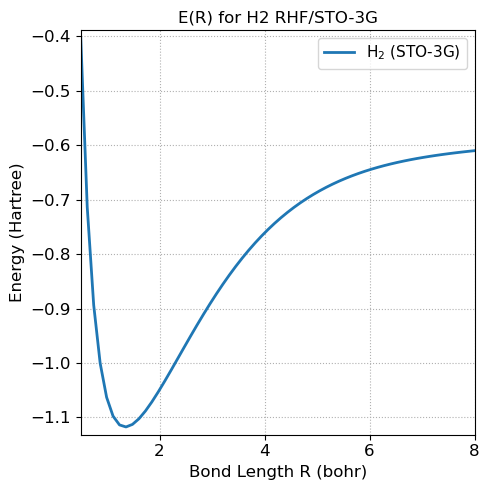

In [10]:
# compute energy as a function of bond length
bond_lengths = np.linspace(0.5, 8.0, 62)
energies = []
# loop over R values and compute energies
for R in bond_lengths:
    mol = H2RHF(bond_length=R)
    energies.append(mol.scf(verbose=False))

# Convert to numpy array
energies = np.array(energies)

#plot 
import matplotlib.pyplot as plt
fontsize = 12
plt.figure(figsize=(5, 5))

plt.plot(bond_lengths, energies, linewidth=2, label='H$_2$ (STO-3G)')

plt.xlabel('Bond Length R (bohr)', fontsize=fontsize)
plt.ylabel('Energy (Hartree)', fontsize=fontsize)

plt.title('E(R) for H2 RHF/STO-3G', fontsize=fontsize)

plt.legend(fontsize=fontsize-1)
plt.grid(True, linestyle=':', linewidth=0.8)

plt.tick_params(labelsize=fontsize)

# Tight axis limits (no excess whitespace)
plt.xlim(bond_lengths.min(), bond_lengths.max())

# Optional: tighten y-limits to data range with small padding
ymin = energies.min()
ymax = energies.max(),
padding = 0.02 * (ymax - ymin)
plt.ylim(ymin - padding, ymax + padding)

plt.tight_layout()
plt.show()


## 8. Short assignment

### Part A
Create a `Triangle` class analgous to our `Rectangle` class that inputs the appropriate information and is able to compute the area and perimeter of the triangle as well as print a summary.


In [11]:
class Triangle:
    """
    A class to store the unique definition of a triangle with functions to compute the area and perimeter of the triangle.
    """
    def __init__(self, input_variable_1, input_variable_2, input_variable_3):
        """ The initialization function """

### you need to add the rest...

### Part B
Modify the `H2RHF` class so that `nuclear_charges` and `basis_type` can be passed into `__init__` instead of hard-coding them.

### Part C
Compute and ***plot*** E(R) vs R ($0.5 \leq R \leq 8$ Bohr) for H$_2$ in the following bases:

- sto-3g
- sto-6g

Plot both on the same plot and label the plot accordingly.  Which has a lower energy and why?

### Part D
Compute and ***plot*** $E(R)$ vs $R$ ($0.7 \leq R \leq 8$ Bohr) for HeH$^+$ in an sto-3g basis.  Describe any differences observed between $E(R)$ for $HeH$^+$ and $H_2$ (from above).  Why is the asymptotic 